# Task 3: Heart Disease Prediction
### DevelopersHub Corporation — AI/ML Engineering Internship
**Author:** Abdul Samad

---
## Goal
Predict whether a patient **has heart disease or not** using 13 medical measurements.
- Output `1` = Heart disease present
- Output `0` = No heart disease

This is **Binary Classification** — the model answers yes or no for each patient.

---
## 📦 Block 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)

print('✅ Libraries loaded!')

✅ Libraries loaded!


---
## 📥 Block 2: Load Dataset

### About this CSV
This is the **multi-source Heart Disease UCI dataset** — 920 patients from 4 hospitals.
It has some important differences from the classic version:
- Column `num` (0–4) is the target — we convert it to binary (0 = healthy, 1 = disease)
- Column `thalch` is max heart rate (not `thalach`)
- Several columns use **text values** like `'Male'`, `'asymptomatic'` — we encode these
- **1,759 missing values** across multiple columns — we fill with median
- Columns `id` and `dataset` are just labels — not useful for prediction

In [2]:
# Load the raw dataset
df_raw = pd.read_csv('heart.csv')

print(f'Raw shape   : {df_raw.shape}  →  {df_raw.shape[0]} patients, {df_raw.shape[1]} columns')
print(f'\nColumns     : {df_raw.columns.tolist()}')
print(f'\nMissing values per column:')
print(df_raw.isnull().sum())
print(f'\nTotal missing: {df_raw.isnull().sum().sum()}')
print(f'\nTarget column (num) values:')
print(df_raw['num'].value_counts())
print(f'\nFirst 3 rows:')
display(df_raw.head(3))

Raw shape   : (920, 16)  →  920 patients, 16 columns

Columns     : ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Total missing: 1759

Target column (num) values:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

First 3 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1


---
## 🧹 Block 3: Data Cleaning & Preprocessing

This dataset needs significant cleaning before it can be used:

| Problem | Fix |
|---|---|
| `id` and `dataset` columns are useless | Drop them |
| Target column is `num` (0–4), not `target` | Convert to binary: 0 stays 0, 1–4 become 1 |
| `sex`, `cp`, `restecg`, `slope`, `thal` are text | Encode to numbers |
| `fbs`, `exang` are True/False | Encode to 1.0 / 0.0 |
| 1,759 missing values across 10 columns | Fill each column with its median |
| Column named `thalch` | Rename to `thalach` for clarity |

In [ ]:
# Work on a fresh copy — never modify raw data
df = df_raw.copy()

# ── Step 1: Drop useless columns ──────────────────────────
# 'id' is just a row number, 'dataset' is the hospital name
# Neither has any medical meaning for prediction
df = df.drop(['id', 'dataset'], axis=1)

# ── Step 2: Create binary target from num ─────────────────
# Original: 0=no disease, 1/2/3/4=varying disease severity
# We simplify: 0=no disease, 1=any disease (binary classification)
df['target'] = (df['num'] > 0).astype(int)
df = df.drop('num', axis=1)

# ── Step 3: Rename thalch → thalach ───────────────────────
df = df.rename(columns={'thalch': 'thalach'})

# ── Step 4: Encode text columns to numbers ────────────────
# sex: Male → 1.0, Female → 0.0
df['sex'] = (df['sex'] == 'Male').astype(float)

# fbs and exang: True → 1.0, False → 0.0
df['fbs']   = df['fbs'].map({True: 1.0, False: 0.0})
df['exang'] = df['exang'].map({True: 1.0, False: 0.0})

# cp (chest pain type): text → ordered numbers
# 0=typical angina (most typical), 3=asymptomatic (no pain despite disease)
df['cp'] = df['cp'].map({
    'typical angina'  : 0,
    'atypical angina' : 1,
    'non-anginal'     : 2,
    'asymptomatic'    : 3
})

# restecg (resting ECG result)
df['restecg'] = df['restecg'].map({
    'normal'          : 0,
    'st-t abnormality': 1,
    'lv hypertrophy'  : 2
})

# slope (ST segment shape during exercise)
df['slope'] = df['slope'].map({
    'upsloping'  : 0,
    'flat'       : 1,
    'downsloping': 2
})

# thal (blood disorder type)
df['thal'] = df['thal'].map({
    'normal'           : 1,
    'fixed defect'     : 2,
    'reversable defect': 3
})

# ── Step 5: Fill missing values with median 
# Median is more good than mean as it ignores extreme outliers
# We apply column by column so each uses its own median
for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  Filled {col:<12} — {n_missing:>3} missing → median = {median_val}')

# ── Verify everything is clean ────────────────────────────
print(f'\n✅ Cleaning complete!')
print(f'   Shape          : {df.shape}')
print(f'   Missing values : {df.isnull().sum().sum()}  (must be 0)')
print(f'   All numeric    : {all(df.dtypes != object)}')
print(f'   Target balance :')
counts = df['target'].value_counts()
total  = len(df)
print(f'     No Disease    (0): {counts[0]}  ({counts[0]/total*100:.1f}%)')
print(f'     Heart Disease (1): {counts[1]}  ({counts[1]/total*100:.1f}%)')

  Filled trestbps     —  59 missing → median = 130.0
  Filled chol         —  30 missing → median = 223.0
  Filled fbs          —  90 missing → median = 0.0
  Filled restecg      —   2 missing → median = 0.0
  Filled thalach      —  55 missing → median = 140.0
  Filled exang        —  55 missing → median = 0.0
  Filled oldpeak      —  62 missing → median = 0.5
  Filled slope        — 309 missing → median = 1.0
  Filled ca           — 611 missing → median = 0.0
  Filled thal         — 486 missing → median = 2.0

✅ Cleaning complete!
   Shape          : (920, 14)
   Missing values : 0  (must be 0)
   All numeric    : True
   Target balance :
     No Disease    (0): 411  (44.7%)
     Heart Disease (1): 509  (55.3%)


---
## 📊 Block 4: EDA — 2 Essential Plots

Before training, we answer two questions:
1. Which features look different between sick and healthy patients?
2. Which features are most correlated with heart disease?

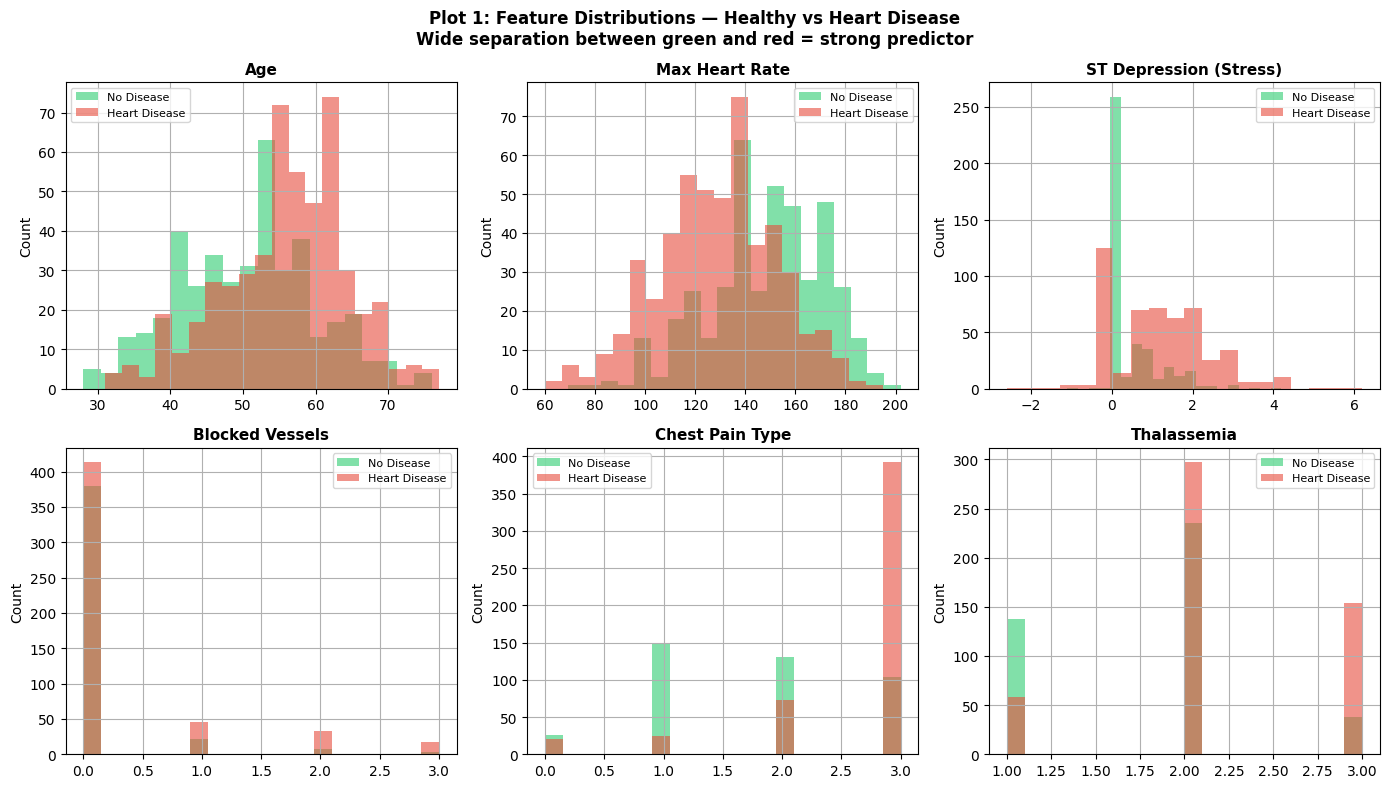

💾 Saved!


In [4]:
# ── PLOT 1: Feature Comparison — Sick vs Healthy ──────────
#
# Two overlapping histograms per feature:
#   Green = healthy patients (target=0)
#   Red   = heart disease patients (target=1)
#
# What to look for:
#   Wide gap between green and red = strong predictor
#   Completely overlapping bars = not very useful

features_to_plot = ['age', 'thalach', 'oldpeak', 'ca', 'cp', 'thal']
feature_labels   = [
    'Age',
    'Max Heart Rate',
    'ST Depression (Stress)',
    'Blocked Vessels',
    'Chest Pain Type',
    'Thalassemia'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, feat, label in zip(axes, features_to_plot, feature_labels):
    df[df['target'] == 0][feat].hist(
        ax=ax, bins=20, alpha=0.6, color='#2ECC71', label='No Disease'
    )
    df[df['target'] == 1][feat].hist(
        ax=ax, bins=20, alpha=0.6, color='#E74C3C', label='Heart Disease'
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle(
    'Plot 1: Feature Distributions — Healthy vs Heart Disease\n'
    'Wide separation between green and red = strong predictor',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/plot1_feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved!')

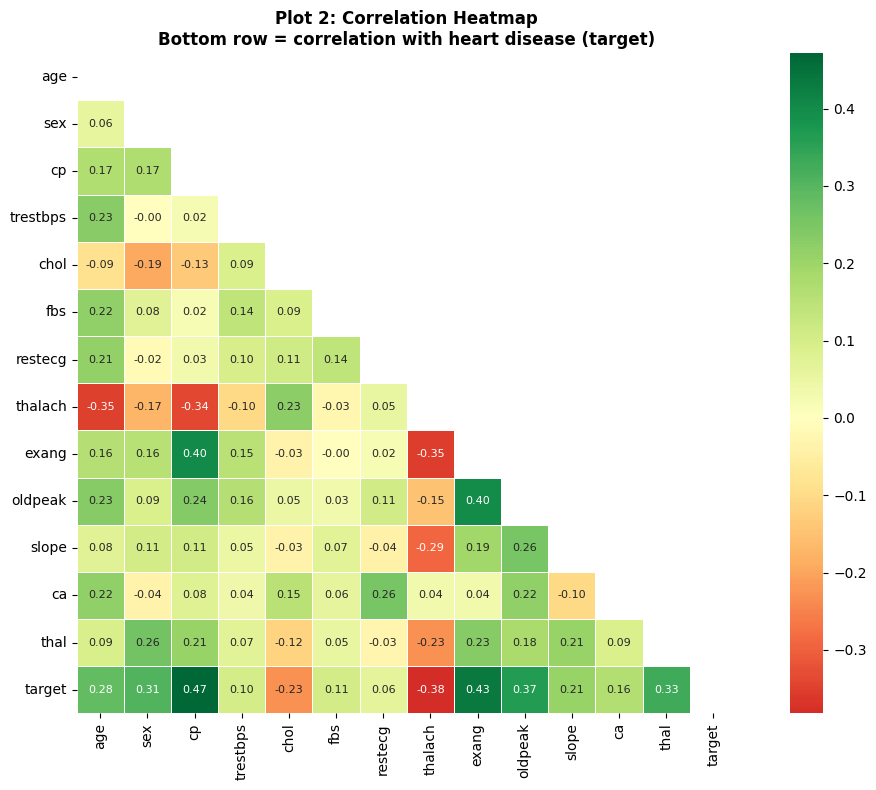

💾 Saved!

Top features correlated with heart disease:
  cp           +0.472   (higher = more risk)
  exang        +0.434   (higher = more risk)
  thalach      -0.382   (lower = more risk)
  oldpeak      +0.366   (higher = more risk)
  thal         +0.331   (higher = more risk)
  sex          +0.307   (higher = more risk)


In [5]:
# ── PLOT 2: Correlation Heatmap ────────────────────────────
#
# Shows how strongly each feature relates to every other feature
#   +1.0 = perfectly linked in same direction
#   -1.0 = perfectly linked in opposite direction
#    0.0 = no relationship
#
# The bottom row (target) tells us which features predict heart disease

fig, ax = plt.subplots(figsize=(11, 8))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide duplicate upper triangle

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn',  # Red=negative, Yellow=neutral, Green=positive
    center=0, square=True, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)

ax.set_title(
    'Plot 2: Correlation Heatmap\n'
    'Bottom row = correlation with heart disease (target)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/plot2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved!')

# Print the top correlations in plain text
print('\nTop features correlated with heart disease:')
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
for feat, val in target_corr.head(6).items():
    direction = 'higher = more risk' if val > 0 else 'lower = more risk'
    print(f'  {feat:<12} {val:+.3f}   ({direction})')

---
## 🛠️ Block 5: Prepare Data for Training

In [6]:
# Separate inputs from the answer we want to predict
X = df.drop('target', axis=1)  # all 13 medical features
y = df['target']               # 0 or 1

# Train/test split: 80% training, 20% testing
# stratify=y ensures both splits have the same % of sick/healthy
# This prevents an unlucky split where all sick patients land in one set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale all features to the same range
# Without scaling, 'chol' (value ~200) would dwarf 'sex' (value 0/1)
# and the model would think cholesterol is far more important
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn scale from train only
X_test_scaled  = scaler.transform(X_test)       # apply same scale to test

print(f'Training patients : {len(X_train)}')
print(f'Testing  patients : {len(X_test)}')
print(f'Features          : {X.shape[1]}')
print('\n✅ Ready to train!')

Training patients : 736
Testing  patients : 184
Features          : 13

✅ Ready to train!


---
## 🤖 Block 6: Train Both Models

| Model | Simple Explanation |
|---|---|
| **Logistic Regression** | Finds the best boundary line between sick and healthy patients |
| **Decision Tree** | Asks yes/no questions: "Is cp=3?" → "Is thalach < 140?" → disease? |

In [7]:
# ── Model 1: Logistic Regression ──────────────────────────
# max_iter=1000 — gives it enough steps to converge on this larger dataset
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)            # yes/no prediction
lr_probs = lr_model.predict_proba(X_test_scaled)[:,1] # probability (0.0–1.0)
print('✅ Logistic Regression trained!')

# ── Model 2: Decision Tree ─────────────────────────────────
# max_depth=5  — limits how many questions deep the tree goes
#                prevents memorizing training data (overfitting)
# min_samples_leaf=5 — each final answer needs 5+ patients behind it
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train_scaled, y_train)

dt_preds = dt_model.predict(X_test_scaled)
dt_probs = dt_model.predict_proba(X_test_scaled)[:,1]
print('✅ Decision Tree trained!')

✅ Logistic Regression trained!
✅ Decision Tree trained!


---
## 📊 Block 7: Evaluate — Accuracy, Confusion Matrix, ROC Curve

### Metrics explained simply:
| Metric | Plain English |
|---|---|
| **Accuracy** | Out of all patients, what % did we get right? |
| **Recall** | Of all sick patients, how many did we catch? ← most important in medicine |
| **Precision** | Of patients we flagged as sick, how many actually were? |
| **ROC-AUC** | Overall ability to separate sick from healthy (1.0 = perfect) |

> ⚠️ **Recall matters most here.** Missing a sick patient (false negative) is worse than a false alarm.

In [8]:
# Print accuracy + detailed report for both models
for name, preds, probs in [
    ('Logistic Regression', lr_preds, lr_probs),
    ('Decision Tree',       dt_preds, dt_probs)
]:
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    print(f'\n{"="*52}')
    print(f'  {name}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.1f}%)')
    print(f'  ROC-AUC  : {auc:.4f}')
    print()
    print(classification_report(
        y_test, preds,
        target_names=['No Disease', 'Heart Disease']
    ))

# Store final scores for plots below
lr_acc = accuracy_score(y_test, lr_preds)
dt_acc = accuracy_score(y_test, dt_preds)
lr_auc = roc_auc_score(y_test, lr_probs)
dt_auc = roc_auc_score(y_test, dt_probs)


  Logistic Regression
  Accuracy : 0.8315  (83.2%)
  ROC-AUC  : 0.8949

               precision    recall  f1-score   support

   No Disease       0.81      0.80      0.81        82
Heart Disease       0.84      0.85      0.85       102

     accuracy                           0.83       184
    macro avg       0.83      0.83      0.83       184
 weighted avg       0.83      0.83      0.83       184


  Decision Tree
  Accuracy : 0.7717  (77.2%)
  ROC-AUC  : 0.8327

               precision    recall  f1-score   support

   No Disease       0.73      0.77      0.75        82
Heart Disease       0.81      0.77      0.79       102

     accuracy                           0.77       184
    macro avg       0.77      0.77      0.77       184
 weighted avg       0.77      0.77      0.77       184



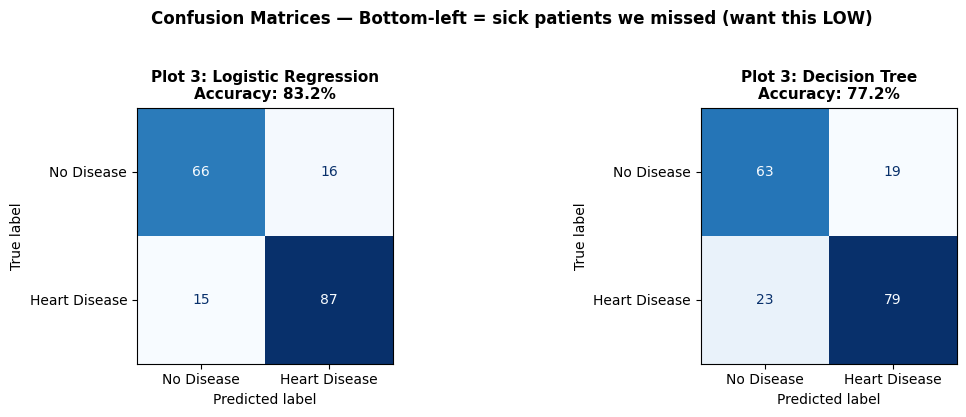

💾 Saved!


In [9]:
# ── PLOT 3: Confusion Matrices ─────────────────────────────
#
# Each matrix shows 4 outcomes:
#
#                Predicted: NO   Predicted: YES
#  Actually: NO   True Neg ✅     False Pos ❌ (false alarm)
#  Actually: YES  False Neg ❌    True Pos  ✅
#                 ↑ MISSED —
#                 worst outcome
#
# Goal: bottom-left box (False Negatives) should be as small as possible

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, name in zip(
    axes,
    [lr_preds, dt_preds],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Disease', 'Heart Disease']
    ).plot(ax=ax, colorbar=False, cmap='Blues')

    acc = accuracy_score(y_test, preds)
    ax.set_title(
        f'Plot 3: {name}\nAccuracy: {acc*100:.1f}%',
        fontsize=11, fontweight='bold'
    )

plt.suptitle(
    'Confusion Matrices — Bottom-left = sick patients we missed (want this LOW)',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('plots/plot3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved!')

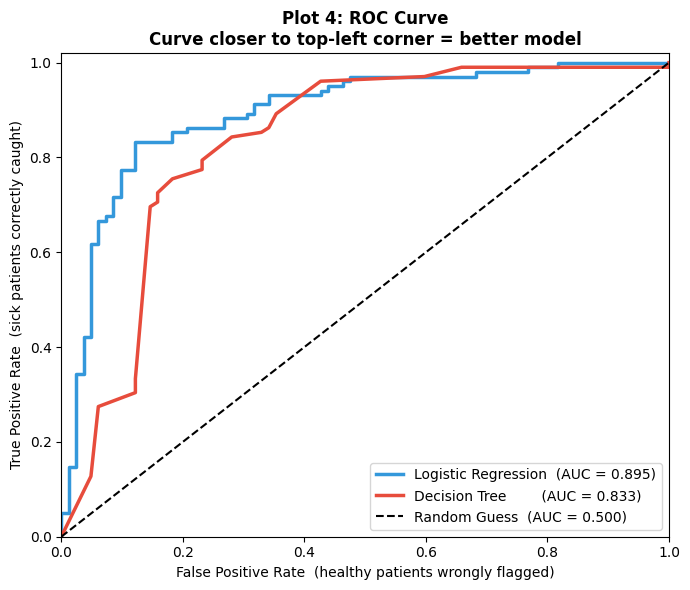

💾 Saved!


In [10]:
# ── PLOT 4: ROC Curves ─────────────────────────────────────
#
# Shows the trade-off between:
#   True Positive Rate  = % of sick patients correctly caught
#   False Positive Rate = % of healthy patients wrongly flagged
#
# Best model = curve hugging the top-left corner
# Dashed diagonal = random guessing (no skill whatsoever)
#
# AUC score:
#   1.00 = perfect | 0.50 = random guess | below 0.50 = worse than random

fig, ax = plt.subplots(figsize=(7, 6))

for probs, name, color in [
    (lr_probs, f'Logistic Regression  (AUC = {lr_auc:.3f})', '#3498DB'),
    (dt_probs, f'Decision Tree        (AUC = {dt_auc:.3f})', '#E74C3C')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=name)

# The diagonal = random guessing baseline
ax.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Random Guess  (AUC = 0.500)')

ax.set_xlabel('False Positive Rate  (healthy patients wrongly flagged)', fontsize=10)
ax.set_ylabel('True Positive Rate  (sick patients correctly caught)', fontsize=10)
ax.set_title(
    'Plot 4: ROC Curve\nCurve closer to top-left corner = better model',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('plots/plot4_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved!')

---
## 🔑 Block 8: Feature Importance

Which health measurements matter most for predicting heart disease?

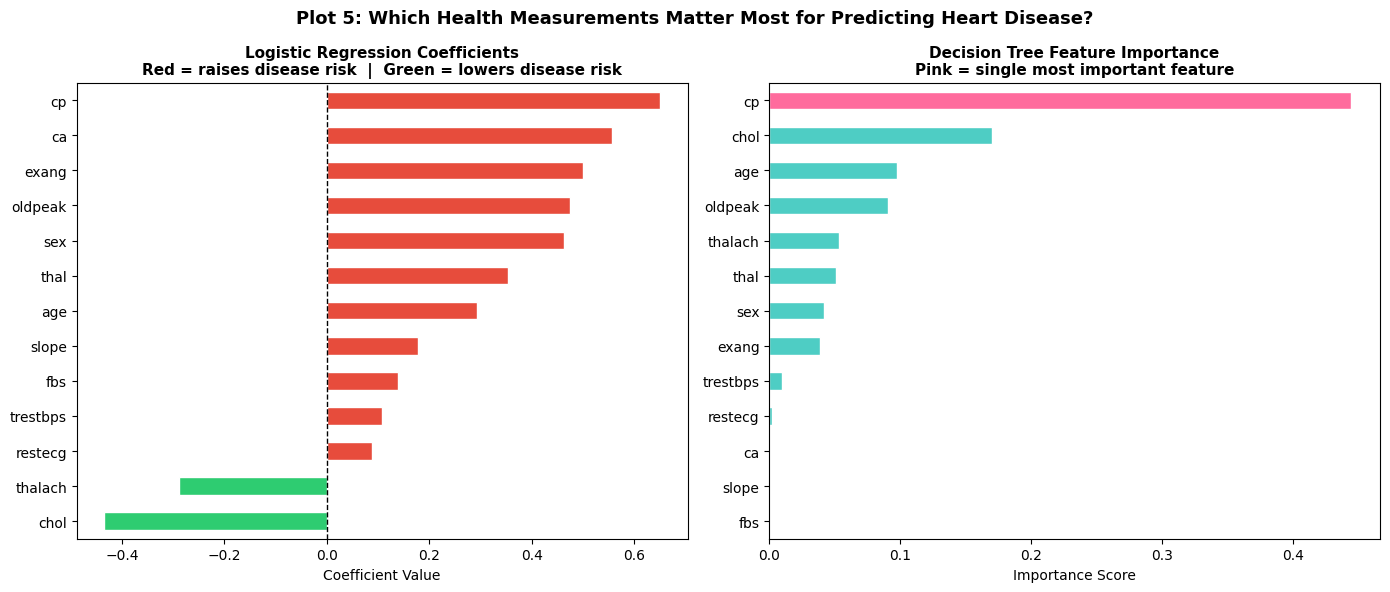

💾 Saved!


In [11]:
# ── PLOT 5: Feature Importance ─────────────────────────────
#
# LEFT — Logistic Regression coefficients:
#   Red bar   = feature INCREASES heart disease risk
#   Green bar = feature DECREASES heart disease risk
#   Longer bar = stronger effect in that direction
#
# RIGHT — Decision Tree Gini importance:
#   Shows how often each feature was used to split patients
#   Longer bar = model relies on this feature more heavily
#   Pink bar   = the single most important feature

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression coefficients
lr_coef  = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()
clr_bars = ['#E74C3C' if v > 0 else '#2ECC71' for v in lr_coef]
lr_coef.plot(kind='barh', ax=axes[0], color=clr_bars, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[0].set_title(
    'Logistic Regression Coefficients\n'
    'Red = raises disease risk  |  Green = lowers disease risk',
    fontsize=11, fontweight='bold'
)
axes[0].set_xlabel('Coefficient Value')

# Decision Tree Gini importance
dt_imp   = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values()
cdt_bars = ['#FF6B9D' if i == dt_imp.index[-1] else '#4ECDC4' for i in dt_imp.index]
dt_imp.plot(kind='barh', ax=axes[1], color=cdt_bars, edgecolor='white')
axes[1].set_title(
    'Decision Tree Feature Importance\n'
    'Pink = single most important feature',
    fontsize=11, fontweight='bold'
)
axes[1].set_xlabel('Importance Score')

plt.suptitle(
    'Plot 5: Which Health Measurements Matter Most for Predicting Heart Disease?',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/plot5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved!')

---
## 🏁 Block 9: Final Summary

In [ ]:
winner = 'Logistic Regression' if lr_auc >= dt_auc else 'Decision Tree'

print('=' * 55)
print('           FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  Dataset    : Heart Disease UCI (multi-source)')
print(f'  Patients   : {len(df)}')
print(f'  Features   : {X.shape[1]}')
print(f'  Train/Test : {len(X_train)} / {len(X_test)} patients')

print(f'\n  {"Model":<25} {"Accuracy":>10} {"ROC-AUC":>10}')
print(f'  {"-"*47}')
print(f'  {"Logistic Regression":<25} {lr_acc:>10.4f} {lr_auc:>10.4f}')
print(f'  {"Decision Tree":<25} {dt_acc:>10.4f} {dt_auc:>10.4f}')
print(f'\n  🏆 Best Model : {winner}')

print(f'\n  KEY FINDINGS')
print(f'  {"-"*47}')
print('  1. cp (chest pain type) is the strongest predictor')
print('     Asymptomatic chest pain = highest disease risk')
print()
print('  2. thalach (max heart rate) — lower = more risk')
print('     Healthy hearts reach higher rates during exercise')
print()
print('  3. ca (blocked vessels) — more blocked = more risk')
print('     Directly reflects how clogged the arteries are')
print()
print('  4. exang (exercise-induced chest pain) = red flag')
print('     Pain under physical stress is a direct disease signal')
print()
print('  5. Age alone is NOT the top predictor')
print('     Heart function tests outperform age every time')

           FINAL RESULTS SUMMARY
  Dataset    : Heart Disease UCI (multi-source)
  Patients   : 920
  Features   : 13
  Train/Test : 736 / 184 patients

  Model                       Accuracy    ROC-AUC
  -----------------------------------------------
  Logistic Regression           0.8315     0.8949
  Decision Tree                 0.7717     0.8327

  🏆 Best Model : Logistic Regression

  KEY FINDINGS
  -----------------------------------------------
  1. cp (chest pain type) is the strongest predictor
     Asymptomatic chest pain = highest disease risk

  2. thalach (max heart rate) — lower = more risk
     Healthy hearts reach higher rates during exercise

  3. ca (blocked vessels) — more blocked = more risk
     Directly reflects how clogged the arteries are

  4. exang (exercise-induced chest pain) = red flag
     Pain under physical stress is a direct disease signal

  5. Age alone is NOT the top predictor
     Heart function tests outperform age every time

  ⚠️  Educational pu